## ✈️ EDA and Feature Engineering — Flight Price Dataset
This is a very good project for your Data Analyst portfolio because it covers both EDA and feature engineering, which are important skills in real-world data analysis.
🎯 Project Objective
Analyze flight prices and identify how different factors affect ticket prices, such as:
- Airline
- Source
- Destination
- Number of stops
- Journey date
- Departure time
- Arrival time
- Duration
- Total stops
- Additional information
- Price

# Stap 1 -- Flight Price Analysis
# 1. Import Libraries
Open Google Colab and create a new notebook.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 2. Load the Dataset

In [ ]:
df = pd.read_excel("/content/Data_Train.xlsx")

# 3. Check First 5 Rows

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


This shows the first 5 records.

# 4. Check Last 5 Rows

In [ ]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


# 5. Check Dataset Shape

In [ ]:
df.shape

(10683, 11)

# 6. Check Column Names

In [ ]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

# 7. Check Data Types

In [ ]:
df.dtypes

,0
Airline,object
Date_of_Journey,object
Source,object
Destination,object
Route,object
Dep_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Additional_Info,object


# 8. Complete Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


# 9. Check Missing Values

In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


# Drop Missing Values

In [ ]:
# remove missing values
df.dropna(inplace=True)


# 10. Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

# Remove Duplicates

In [ ]:
# remove duplicates
df.drop_duplicates(inplace=True)

# 11. Sttatistical Summary

In [ ]:
df.describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


# 12. Analyze Source

In [ ]:
df["Source"].value_counts()

,count
Source,
Delhi,4345
Kolkata,2860
Banglore,2179
Mumbai,697
Chennai,381


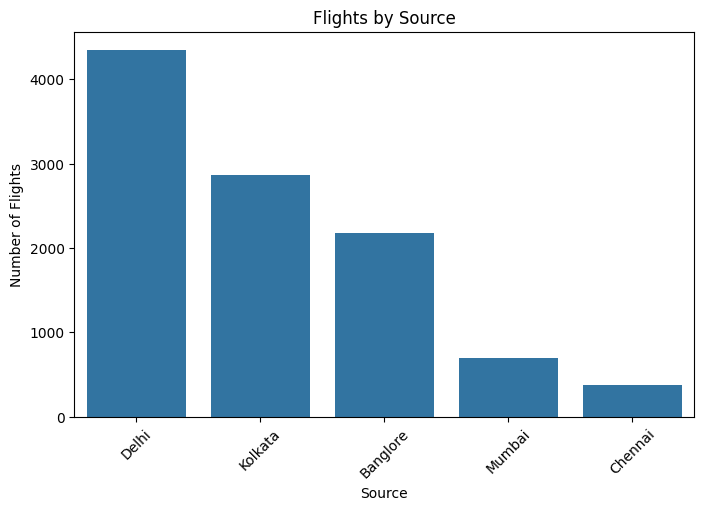

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Source",
    order=df["Source"].value_counts().index
)

plt.title("Flights by Source")
plt.xlabel("Source")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

# 13. Analyze Destination

In [ ]:
df["Destination"].value_counts()

,count
Destination,
Cochin,4345
Banglore,2860
Delhi,1265
New Delhi,914
Hyderabad,697
Kolkata,381


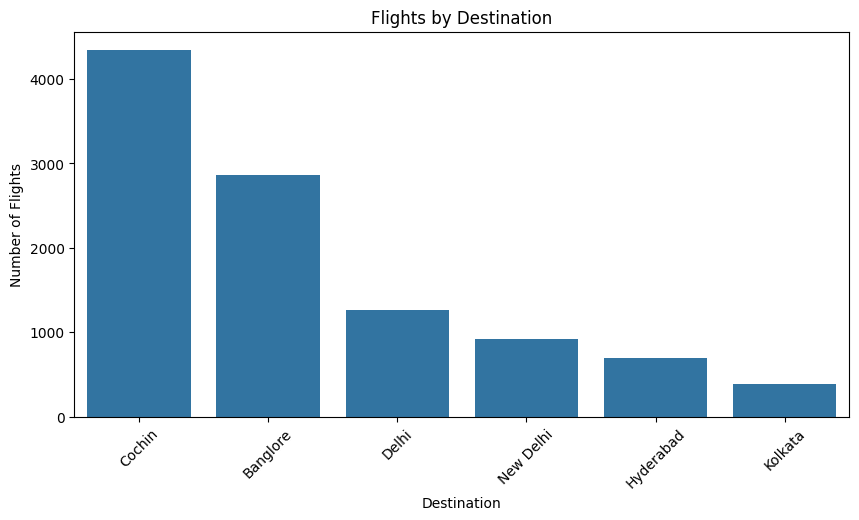

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Destination",
    order=df["Destination"].value_counts().index
)

plt.title("Flights by Destination")
plt.xlabel("Destination")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

# 14. Feature Engineering — Date of Journey
First check the format:

In [ ]:
df["Date_of_Journey"].head()

,Date_of_Journey
0,24/03/2019
1,1/05/2019
2,9/06/2019
3,12/05/2019
4,01/03/2019


Convert to datetime:

In [ ]:
df["Date_of_Journey"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
)

Create day:

In [ ]:
df["Journey_Day"] = df["Date_of_Journey"].dt.day

Create month:

In [ ]:
df["Journey_Month"] = df["Date_of_Journey"].dt.month

Create year:

In [ ]:
df["Journey_Year"] = df["Date_of_Journey"].dt.year

Check

In [ ]:
df[
    [
        "Date_of_Journey",
        "Journey_Day",
        "Journey_Month",
        "Journey_Year"
    ]
].head()

,Date_of_Journey,Journey_Day,Journey_Month,Journey_Year
0,2019-03-24,24,3,2019
1,2019-05-01,1,5,2019
2,2019-06-09,9,6,2019
3,2019-05-12,12,5,2019
4,2019-03-01,1,3,2019


# 15. Journey Month Analysis

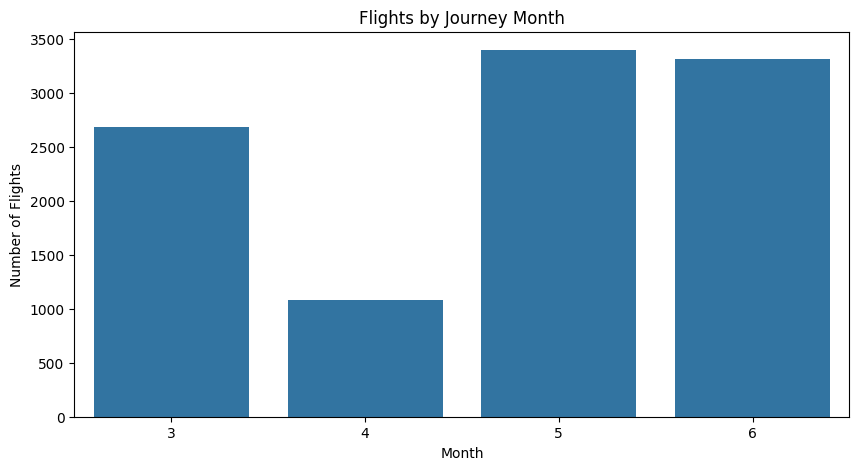

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Journey_Month"
)

plt.title("Flights by Journey Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

# 16. Feature Engineering — Departure Time

In [ ]:
df["Dep_Time"].head()

,Dep_Time
0,22:20
1,05:50
2,09:25
3,18:05
4,16:50


Convert

In [ ]:
df["Dep_Time"] = pd.to_datetime(
    df["Dep_Time"],
    format="%H:%M"
)

Create departure hour

In [ ]:
df["Departure_Hour"] = df["Dep_Time"].dt.hour

Create departure minute

In [ ]:
df["Departure_Minute"] = df["Dep_Time"].dt.minute

# 17. Feature Engineering — Arrival Time
Convert:

In [ ]:
df["Arrival_Time"] = pd.to_datetime(
    df["Arrival_Time"].astype(str).str[:5],
    format="%H:%M"
)

Create arrival hour:

In [ ]:
df["Arrival_Hour"] = df["Arrival_Time"].dt.hour

Create  arrival time


In [ ]:
df["Arrival_Minute"] = df["Arrival_Time"].dt.minute

# 18. Departure Hour Analysis

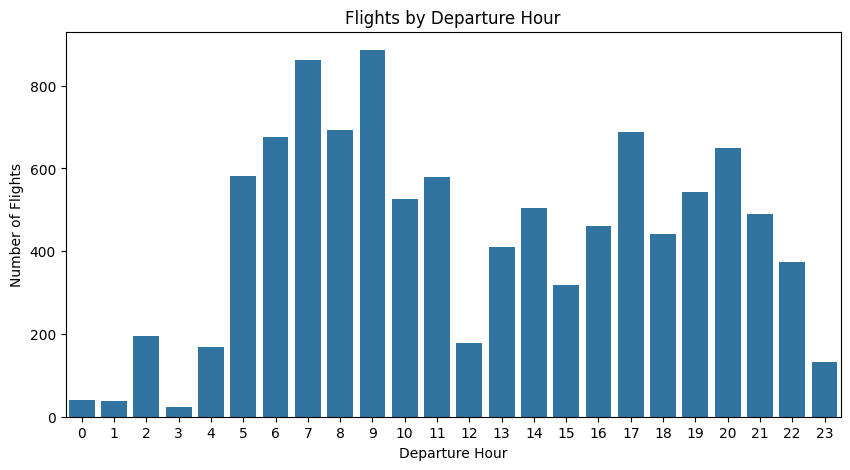

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Departure_Hour"
)

plt.title("Flights by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")
plt.show()

# 19. Duration Distribution

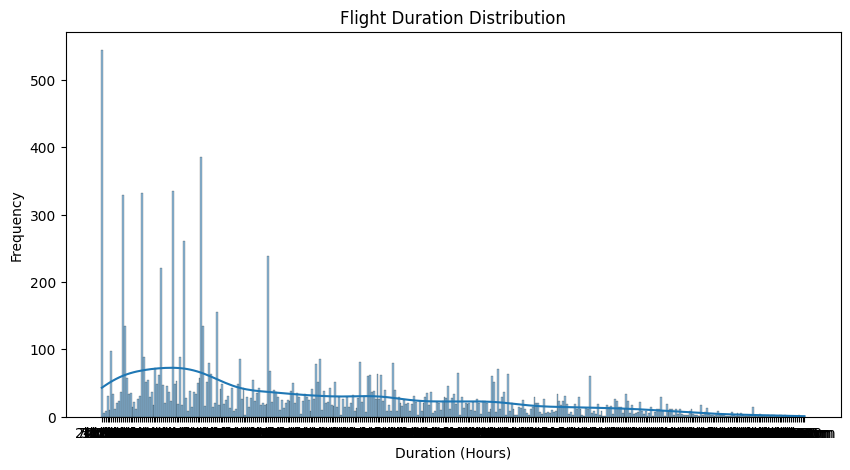

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Duration",
    kde=True
)

plt.title("Flight Duration Distribution")
plt.xlabel("Duration (Hours)")
plt.ylabel("Frequency")
plt.show()

# 20. Analyze Total Stops

In [ ]:
df["Total_Stops"].value_counts()

,count
Total_Stops,
1 stop,5625
non-stop,3475
2 stops,1318
3 stops,43
4 stops,1


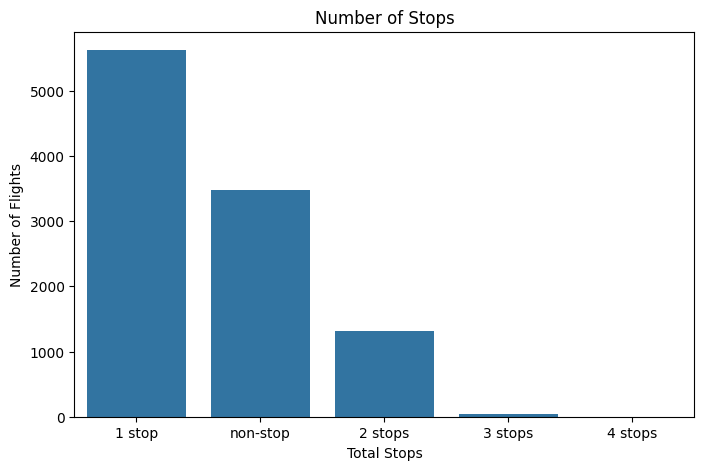

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Total_Stops",
    order=df["Total_Stops"].value_counts().index
)

plt.title("Number of Stops")
plt.xlabel("Total Stops")
plt.ylabel("Number of Flights")
plt.show()

# 21. Convert Total Stops to Numeric

In [ ]:
stop_mapping = {
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}

df["Total_Stops_Numeric"] = (
    df["Total_Stops"].map(stop_mapping)
)

In [ ]:
df[
    [
        "Total_Stops",
        "Total_Stops_Numeric"
    ]
].head()

,Total_Stops,Total_Stops_Numeric
0,non-stop,0
1,2 stops,2
2,2 stops,2
3,1 stop,1
4,1 stop,1


# 22. Price Distribution

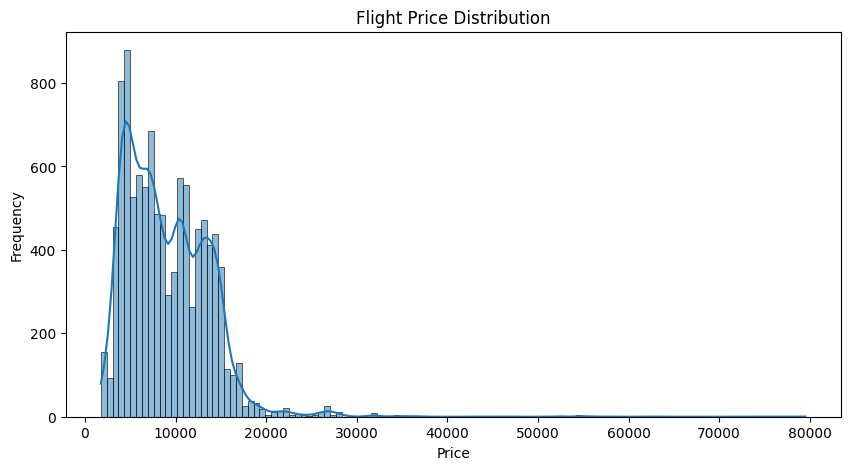

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Price",
    kde=True
)

plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# 23. Price Boxplot

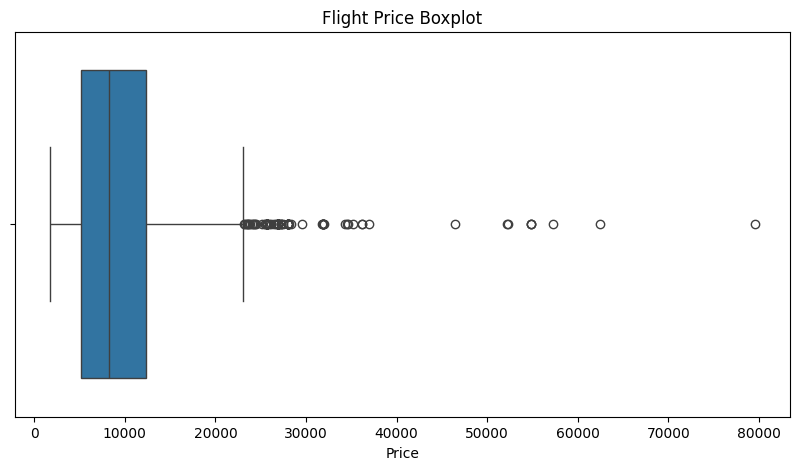

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Price"
)

plt.title("Flight Price Boxplot")
plt.show()

# 24. Airline vs Price

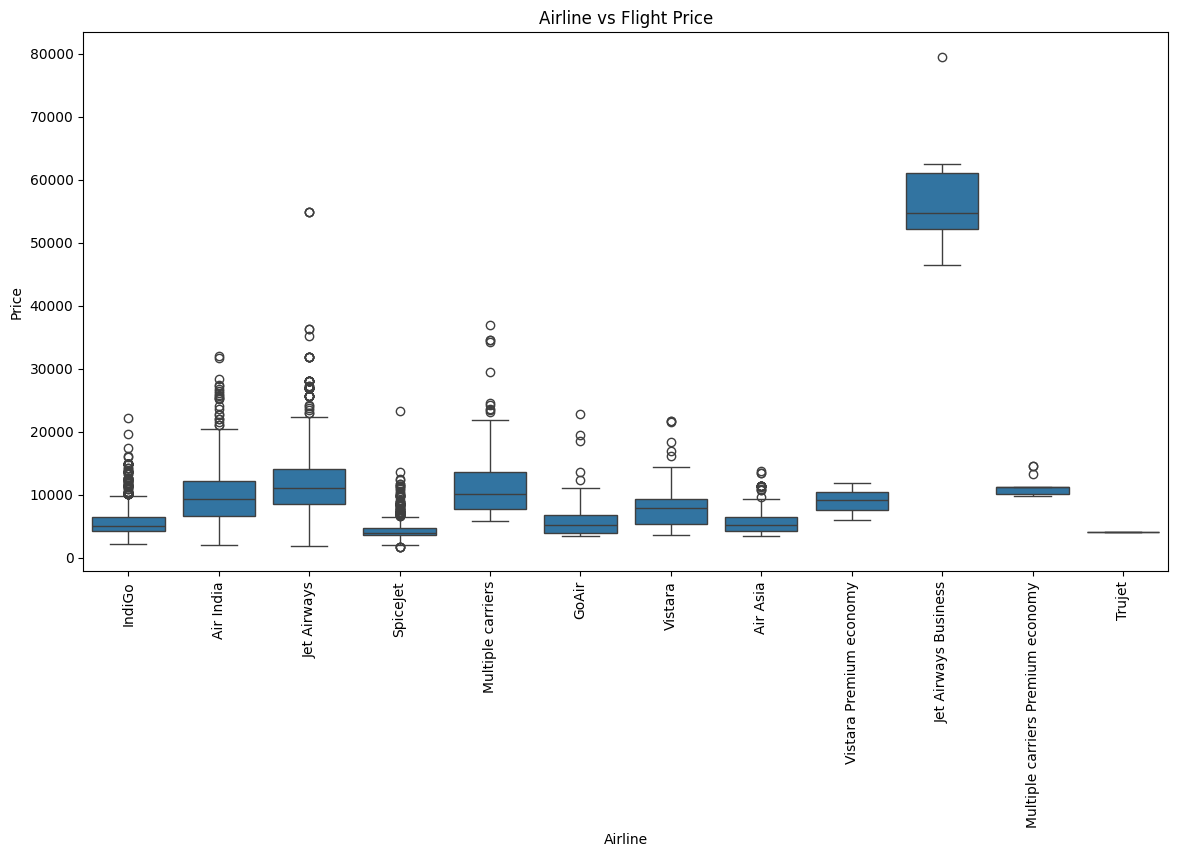

In [ ]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x="Airline",
    y="Price"
)

plt.title("Airline vs Flight Price")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.show()

# 25. Source vs Price

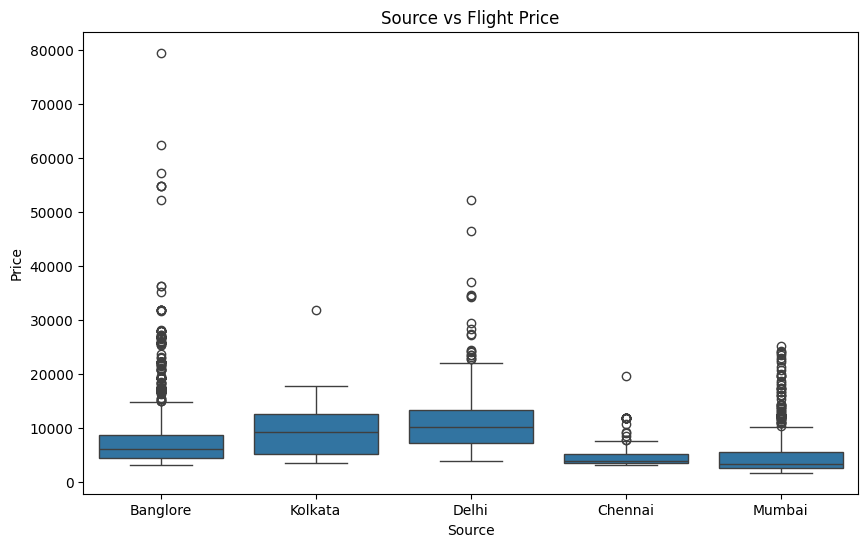

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Source",
    y="Price"
)

plt.title("Source vs Flight Price")
plt.xlabel("Source")
plt.ylabel("Price")
plt.show()

# 26. Destination vs Price

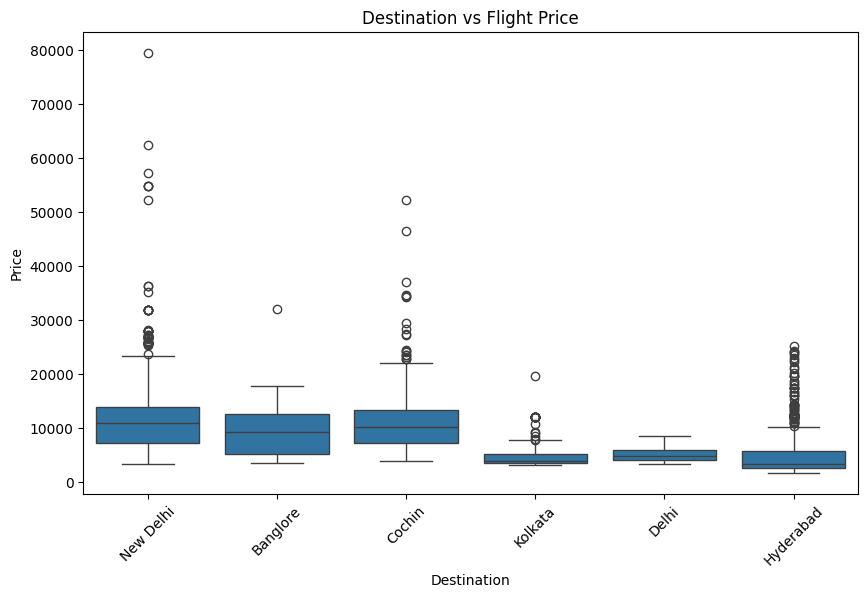

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Destination",
    y="Price"
)

plt.title("Destination vs Flight Price")
plt.xlabel("Destination")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

# 27.  Total Stops vs Price

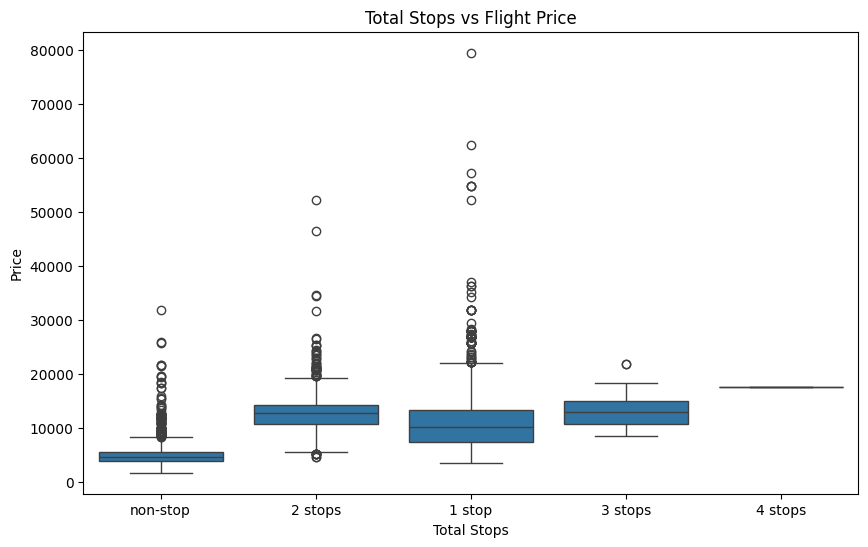

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Total_Stops",
    y="Price"
)

plt.title("Total Stops vs Flight Price")
plt.xlabel("Total Stops")
plt.ylabel("Price")
plt.show()

# 28. Duration vs Price

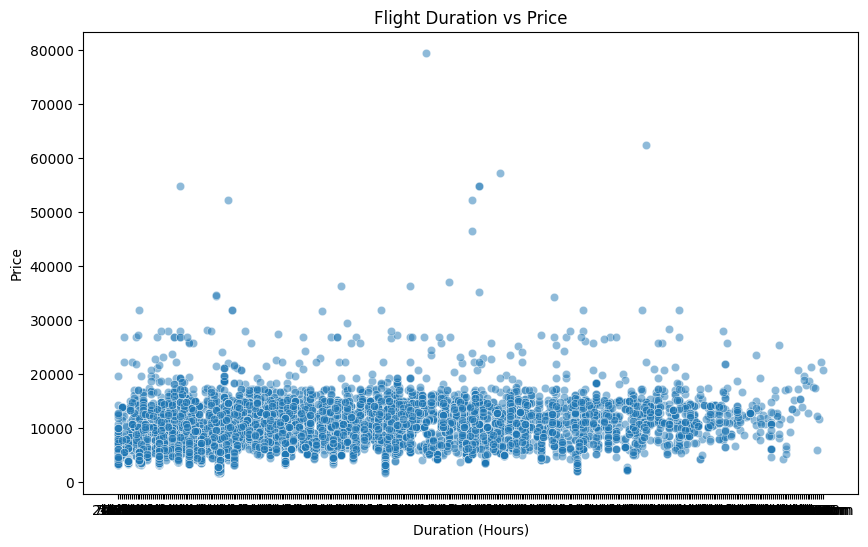

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Duration",
    y="Price",
    alpha=0.5
)

plt.title("Flight Duration vs Price")
plt.xlabel("Duration (Hours)")
plt.ylabel("Price")
plt.show()

In [ ]:
def convert_duration_to_hours(duration_str):
    if pd.isnull(duration_str):
        return np.nan
    parts = duration_str.split(' ')
    hours = 0
    minutes = 0
    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
    return hours + minutes / 60

df['Duration_in_Hours'] = df['Duration'].apply(convert_duration_to_hours)

# 29. Journey Month vs Price

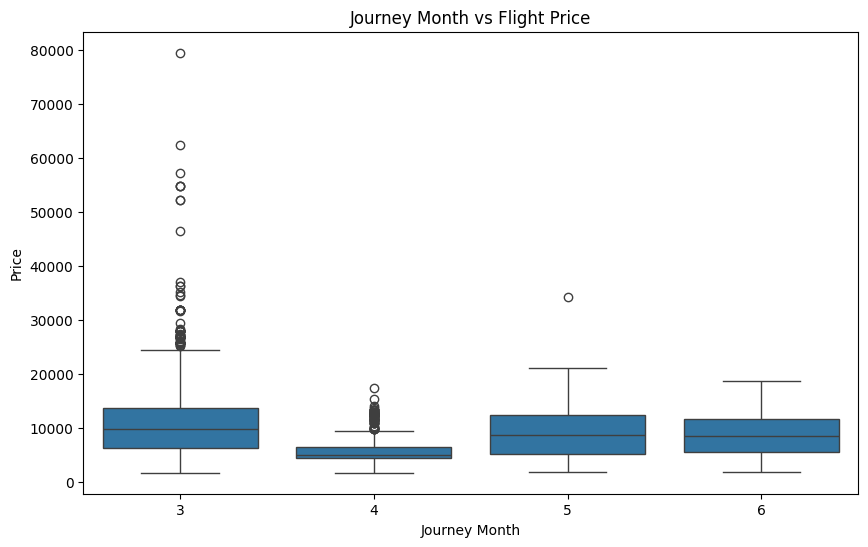

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Journey_Month",
    y="Price"
)

plt.title("Journey Month vs Flight Price")
plt.xlabel("Journey Month")
plt.ylabel("Price")
plt.show()

# 30. Departure Hour vs Price

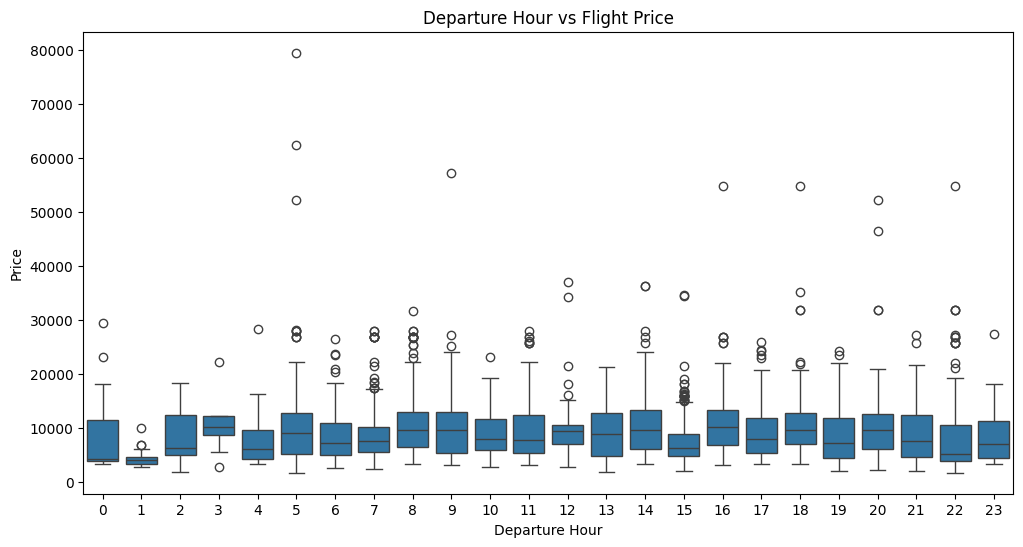

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Departure_Hour",
    y="Price"
)

plt.title("Departure Hour vs Flight Price")
plt.xlabel("Departure Hour")
plt.ylabel("Price")
plt.show()

# 31. Correlation Analysis

In [ ]:
numeric_df = df.select_dtypes(
    include=np.number
)

In [ ]:
correlation = numeric_df.corr()

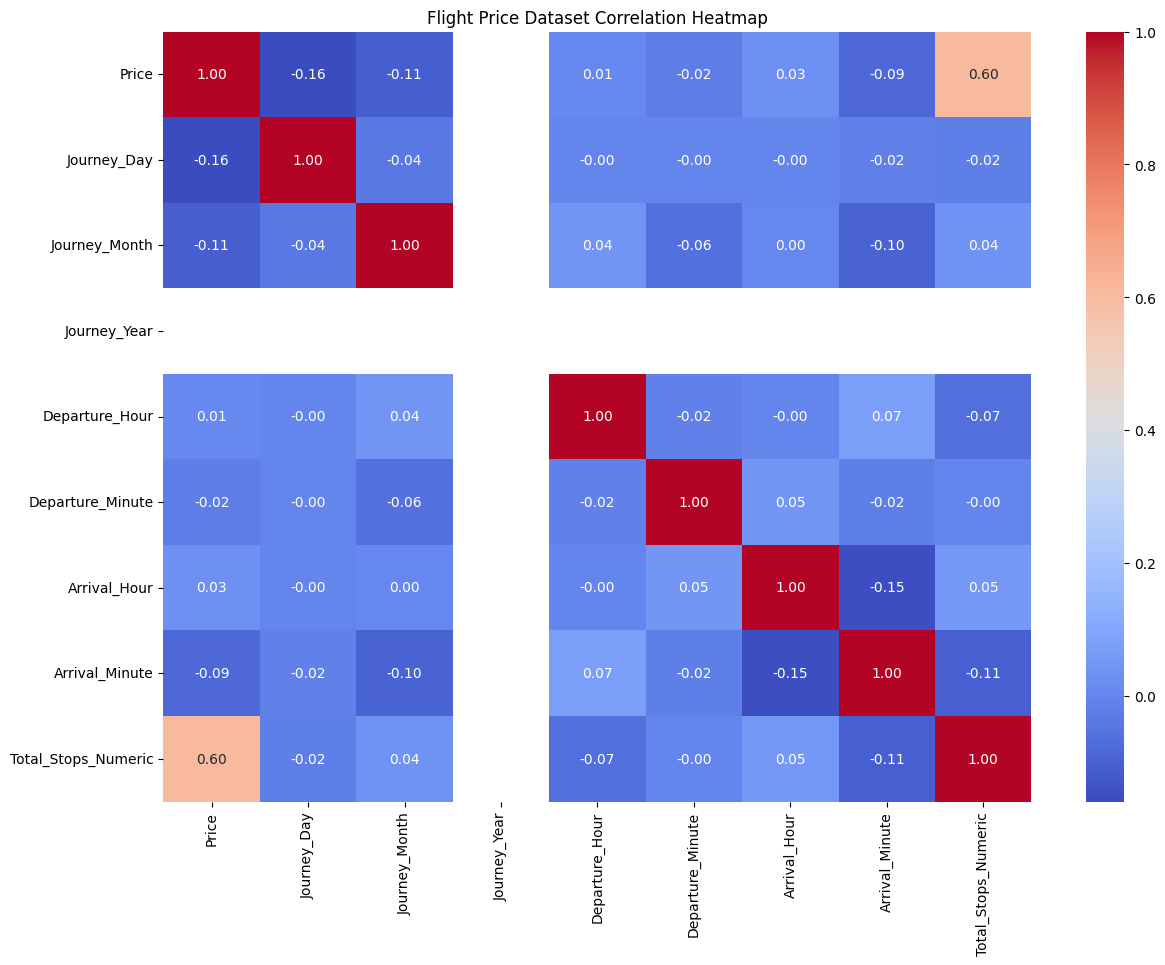

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Flight Price Dataset Correlation Heatmap")
plt.show()

32. Average Price by Airline

In [ ]:
airline_price = (
    df.groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=False)
)

airline_price

,Price
Airline,
Jet Airways Business,58358.666667
Jet Airways,11599.021081
Multiple carriers Premium economy,11418.846154
Multiple carriers,10902.678094
Air India,9556.608028
Vistara Premium economy,8962.333333
Vistara,7801.355649
GoAir,5861.056701
IndiGo,5668.469897


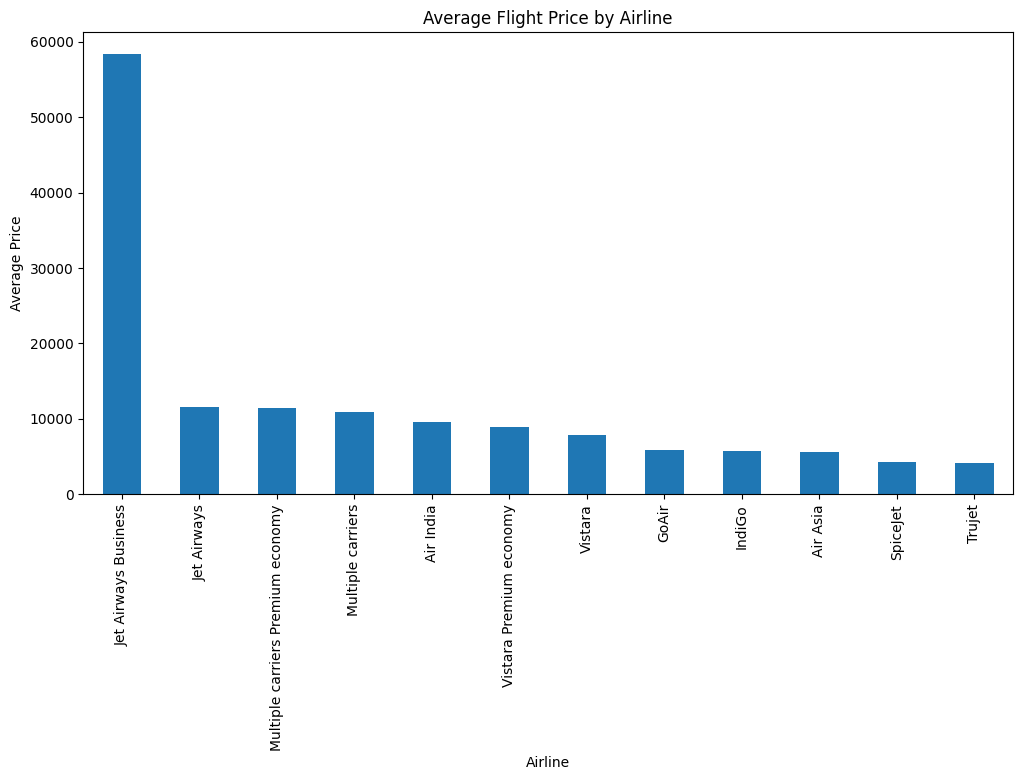

In [ ]:
plt.figure(figsize=(12,6))

airline_price.plot(
    kind="bar"
)

plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.show()

# 33. Average Price by Source

In [ ]:
source_price = (
    df.groupby("Source")["Price"]
    .mean()
    .sort_values(ascending=False)
)

source_price

,Price
Source,
Delhi,10461.600690
Kolkata,9143.083566
Banglore,8022.872877
Mumbai,5059.708752
Chennai,4789.892388


# 34.Average Price by Destination

In [ ]:
destination_price = (
    df.groupby("Destination")["Price"]
    .mean()
    .sort_values(ascending=False)
)

destination_price

,Price
Destination,
New Delhi,12007.421225
Cochin,10461.600690
Banglore,9143.083566
Delhi,5143.918577
Hyderabad,5059.708752
Kolkata,4789.892388


# 35. Average Price by Number of Stops

In [ ]:
stops_price = (
    df.groupby("Total_Stops_Numeric")["Price"]
    .mean()
)

stops_price

,Price
Total_Stops_Numeric,
0,5018.506763
1,10594.123556
2,12761.099393
3,13260.674419
4,17686.000000


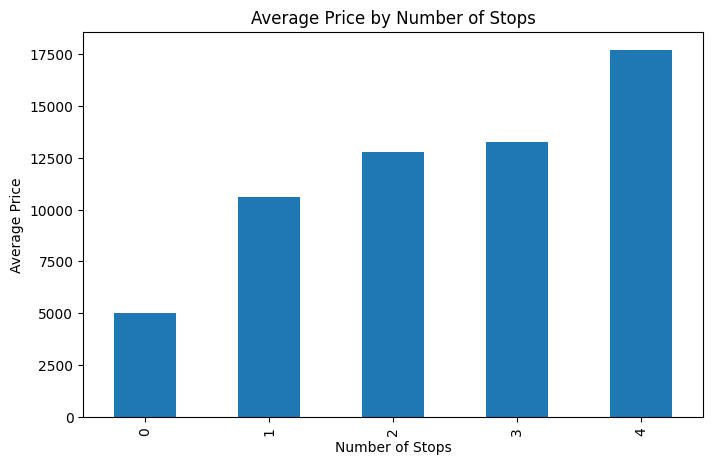

In [ ]:
plt.figure(figsize=(8,5))

stops_price.plot(
    kind="bar"
)

plt.title("Average Price by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Average Price")
plt.show()

# 36. 40. Feature Engineering — Time of Day

In [ ]:
def time_of_day(hour):

    if hour < 6:
        return "Night"

    elif hour < 12:
        return "Morning"

    elif hour < 18:
        return "Afternoon"

    else:
        return "Evening"

In [ ]:
df["Departure_Time_Category"] = (
    df["Departure_Hour"].apply(time_of_day)
)

In [ ]:
df["Departure_Time_Category"].value_counts()

,count
Departure_Time_Category,
Morning,4224
Evening,2629
Afternoon,2563
Night,1046


# 37. Time of Day vs Price

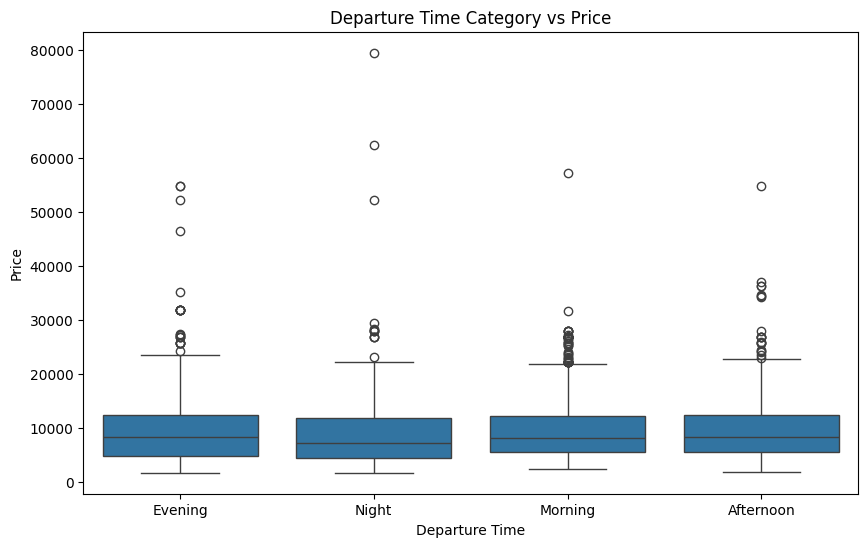

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Departure_Time_Category",
    y="Price"
)

plt.title("Departure Time Category vs Price")
plt.xlabel("Departure Time")
plt.ylabel("Price")
plt.show()

# 38. Final EDA Summary

In [ ]:
print("========== FLIGHT PRICE EDA SUMMARY ==========")

print("Total Records:", len(df))

print(
    "Total Features:",
    df.shape[1]
)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Average Flight Price:",
    round(df["Price"].mean(), 2)
)

print(
    "Minimum Flight Price:",
    df["Price"].min()
)

print(
    "Maximum Flight Price:",
    df["Price"].max()
)


========== FLIGHT PRICE EDA SUMMARY ==========
Total Records: 10462
Total Features: 20
Missing Values: 0
Duplicate Rows: 2
Average Flight Price: 9026.79
Minimum Flight Price: 1759
Maximum Flight Price: 79512


# 39. Dashboard

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create dashboard
fig = make_subplots(
    rows=4,
    cols=3,

    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "bar"},       {"type": "box"},       {"type": "box"}],
        [{"type": "bar"},       {"type": "box"},       {"type": "scatter"}],
        [{"type": "heatmap"},   None,                   None]
    ],

    subplot_titles=[
        "Total Flights",
        "Average Flight Price",
        "Max Flight Price",
        "Airlines",
        "Price by Airline",
        "Monthly Price",
        "Source/Destination",
        "Stops vs Price",
        "Duration vs Price",
        "Correlation Heatmap",
    ],
      vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# Total Flights
fig.add_trace(
    go.Indicator(
        mode="number",
        value=len(df),
    ),
    row=1,
    col=1
)

# Average Flight Price
fig.add_trace(
    go.Indicator(
        mode="number",
        value=df["Price"].mean(),
        number={'valueformat': '.2f'}
    ),
    row=1,
    col=2
)

# Max Flight Price
fig.add_trace(
    go.Indicator(
        mode="number",
        value=df["Price"].max(),
        number={'valueformat': '.2f'}
    ),
    row=1,
    col=3
)

# Airlines (count of flights)
airline_counts = df["Airline"].value_counts()
fig.add_trace(
    go.Bar(
        x=airline_counts.index,
        y=airline_counts.values,
    ),
    row=2,
    col=1
)

# Price by Airlines
fig.add_trace(
    go.Box(
        x=df["Airline"],
        y=df["Price"],
    ),
    row=2,
    col=2
)

# Monthly Price
fig.add_trace(
    go.Box(
        x=df["Journey_Month"],
        y=df["Price"],
    ),
    row=2,
    col=3
)

# Source / Destination
source_price = (
    df.groupby("Source")["Price"]
    .mean()
    .sort_values(ascending=False)
)
fig.add_trace(
    go.Bar(
        x=source_price.index,
        y=source_price.values,
    ),
    row=3,
    col=1
)

# Stops vs Price
fig.add_trace(
    go.Box(
        x=df["Total_Stops"],
        y=df["Price"],
    ),
    row=3,
    col=2
)

# Duration vs Price
fig.add_trace(
    go.Scatter(
        x=df["Duration"],
        y=df["Price"],
        mode='markers',
        marker=dict(opacity=0.5)
    ),
    row=3,
    col=3
)
# Correlation Heatmap
fig.add_trace(
    go.Heatmap(
        z=correlation.values,
        x=correlation.columns,
        y=correlation.index,
        colorscale='Viridis',
    ),
    row=4,
    col=1
)


fig.update_layout(
    title={
        'text': '✈️ FLIGHT PRICE ANALYSIS DASHBOARD',
        'x': 0.5
    },

    height=1400,
    width=1400,

    template='plotly_white',

    showlegend=False
)
fig.show()

# 40. Final EDA Conclusions

## Final EDA Conclusions

1. The Flight Price dataset contains flight information across different airlines, sources, destinations, journey dates, durations, stops, and prices.

2. Data cleaning was performed by checking missing values, duplicate records, inconsistent values, and unnecessary information.

3. Date and time columns were transformed into useful numerical features such as journey day, journey month, departure hour, and arrival hour.

4. Flight duration was converted from text format into minutes and hours for easier analysis.

5. The number of stops was converted into a numerical feature to support analysis.

6. Exploratory analysis showed differences in flight prices across airlines, sources, destinations, and numbers of stops.

7. Flight duration and price were analyzed using scatterplots to understand their relationship.

8. Correlation analysis was performed to identify relationships among numerical features.

9. Outlier analysis was performed using boxplots and the IQR method.

10. Categorical features were prepared using one-hot encoding for further analytical or machine learning use.

11. Feature engineering helped transform raw date, time, duration, and stop information into useful analytical variables.

12. The cleaned and transformed dataset is now ready for further analysis or machine learning.